In [1]:
import os
import numpy as np
import librosa
import noisereduce as nr
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, TimeMask
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

train_dir = r"IDMT-ISA-ELECTRIC-ENGINE/train_cut"
test_dir = r"IDMT-ISA-ELECTRIC-ENGINE/test_cut"


In [3]:
def preprocess_audio(file_path, sr=16000, duration=3):
    audio, _ = librosa.load(file_path, sr=44100, duration=duration, mono=True)
    audio = librosa.resample(audio, orig_sr=44100, target_sr=sr)
    audio = nr.reduce_noise(y=audio, sr=sr, stationary=False, prop_decrease=0.2)
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    target_length = int(sr * duration)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    elif len(audio) > target_length:
        audio = audio[:target_length]
    return audio


In [4]:
augment = Compose([
    AddGaussianNoise(min_amplitude=0.02, max_amplitude=0.08, p=0.9),
    TimeStretch(min_rate=0.4, max_rate=1.6, p=0.9),
    PitchShift(min_semitones=-6, max_semitones=6, p=0.9),
    TimeMask(min_band_part=0.1, max_band_part=0.7, p=0.9)
])


In [5]:
def load_data(directory, sr=16000, augment_data=False):
    X, y = [], []
    class_mapping = {
        'engine1_good': 'good',
        'engine2_broken': 'broken',
        'engine3_heavyload': 'heavy_load'
    }
    for folder in ['engine1_good', 'engine2_broken', 'engine3_heavyload']:
        class_dir = os.path.join(directory, folder)
        if not os.path.exists(class_dir):
            print(f"Directory {class_dir} not found")
            continue
        class_label = class_mapping[folder]
        for file in os.listdir(class_dir):
            if file.endswith('.wav'):
                file_path = os.path.join(class_dir, file)
                audio = preprocess_audio(file_path, sr)
                X.append(audio)
                y.append(class_label)
                if augment_data:
                    for _ in range(8):  # Generate 8 augmented versions
                        augmented_audio = augment(samples=audio, sample_rate=sr)
                        X.append(augmented_audio)
                        y.append(class_label)
    return np.array(X), np.array(y)


In [6]:
class AudioDataset(Dataset):
    def __init__(self, audio, labels, processor):
        self.audio = audio
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        audio = self.audio[idx]
        label = self.labels[idx]
        inputs = self.processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [7]:
X_train, y_train = load_data(train_dir, augment_data=True)
X_test, y_test = load_data(test_dir, augment_data=False)

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [8]:
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(X_train, y_train_encoded, test_size=0.3, stratify=y_train_encoded, random_state=42)



In [9]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2ForSequenceClassification.from_pretrained("facebook/wav2vec2-base", num_labels=3, ignore_mismatched_sizes=True)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
train_dataset = AudioDataset(X_train, y_train_encoded, processor)
val_dataset = AudioDataset(X_val, y_val_encoded, processor)
test_dataset = AudioDataset(X_test, y_test_encoded, processor)

In [12]:
training_args = TrainingArguments(
    output_dir="./wav2vec2_motor_classifier",
    eval_strategy="epoch",  # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available()
)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    accuracy = accuracy_score(labels, preds)
    return {"accuracy": accuracy}

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

# Evaluate on test set
test_results = trainer.predict(test_dataset)
test_accuracy = accuracy_score(test_results.label_ids, test_results.predictions.argmax(-1))
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.007600,0.106611,0.982077
2,0.056000,0.027119,0.995674
3,0.001300,0.052511,0.991965
4,0.001000,0.028894,0.995056
5,0.000800,0.029121,0.995056


Test Accuracy: 0.9991


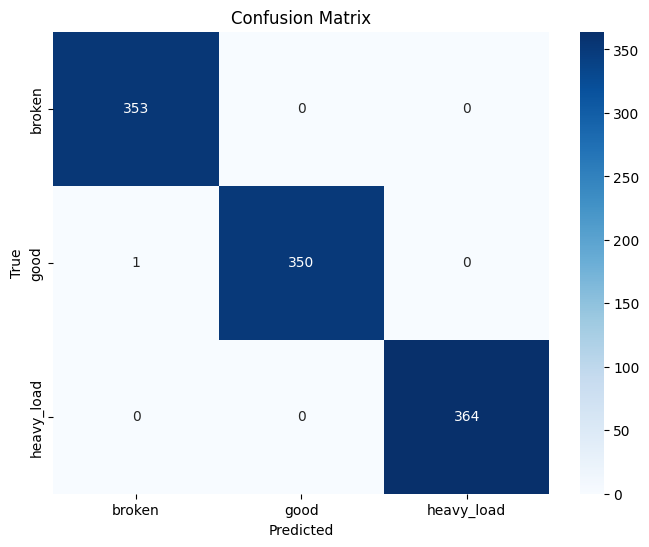

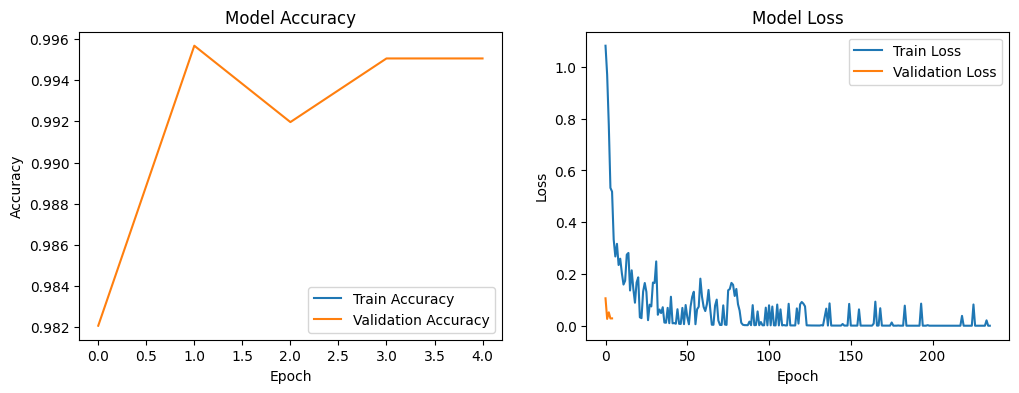

[]

In [14]:
y_pred = test_results.predictions.argmax(-1)
y_true = test_results.label_ids
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plot training history
train_logs = trainer.state.log_history
train_acc, val_acc, train_loss, val_loss = [], [], [], []
for log in train_logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        train_acc.append(log.get('accuracy', None))
    if 'eval_loss' in log:
        val_loss.append(log['eval_loss'])
        val_acc.append(log['eval_accuracy'])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([x for x in train_acc if x], label='Train Accuracy')
plt.plot([x for x in val_acc if x], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save model
trainer.save_model("E:/graduation work/IDMT-ISA-ELECTRIC-ENGINE/wav2vec2_motor_classifier_final")
processor.save_pretrained("E:/graduation work/IDMT-ISA-ELECTRIC-ENGINE/wav2vec2_motor_classifier_final")